# 02 · Cruzamentos: quanto de cada diferença sobra quando se compara alunos parecidos?

No notebook 01, a escola privada ficou 100 pontos acima da pública, e 71
pontos separaram o melhor estado do pior. Mas escola, renda e estado se
misturam: a privada concentra alunos ricos, e alguns estados têm muito mais
alunos pobres que outros. Aqui separamos esses efeitos.

**Método**: padronização (em `src/ajuste.py`). Dividimos os alunos em estratos
de perfil parecido (mesma faixa de renda, mesma escolaridade dos pais),
comparamos dentro de cada estrato e ponderamos. É o mesmo raciocínio de uma
regressão com controles, só que transparente: dá para ver cada comparação.

In [1]:
import sys

sys.path.append("../src")

import matplotlib.pyplot as plt
import pandas as pd

from ajuste import diferenca_ajustada, media_padronizada
from base import carregar, concluintes
from dicionario import FAIXAS_SM, RENDA_SM
from graficos import (AZUL, CINZA, LARANJA, SEQUENCIAL, SUPERFICIE, TEXTO_SECUNDARIO,
                      VERDE_AGUA, aplicar_estilo, salvar)

aplicar_estilo()
pd.set_option("display.float_format", "{:.1f}".format)

base = concluintes(carregar())
base = base[base["TP_ESCOLA"] != "Não respondeu"]  # 5 alunos
base["RENDA_SM"] = pd.Categorical(base["Q006"].map(RENDA_SM), FAIXAS_SM, ordered=True)
print(f"{len(base):,} concluintes de 2023 presentes nas 4 provas")

1,050,858 concluintes de 2023 presentes nas 4 provas


## 1. Pública e privada não têm o mesmo perfil

Antes de comparar notas, compare quem está em cada rede:

In [2]:
composicao = pd.crosstab(base["TP_ESCOLA"], base["RENDA_SM"], normalize="index") * 100
composicao

RENDA_SM,Até 1 SM,1 a 2 SM,2 a 4 SM,4 a 7 SM,Mais de 7 SM
TP_ESCOLA,,,,,
Pública,42.8,29.9,19.1,5.6,2.5
Privada,5.5,12.9,26.1,21.1,34.4


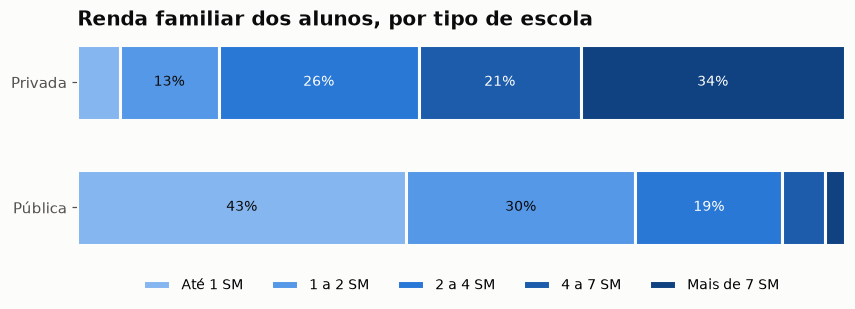

In [3]:
fig, ax = plt.subplots(figsize=(9, 2.6))
cores = [SEQUENCIAL[i] for i in (0, 2, 4, 6, 8)]
esquerda = pd.Series(0.0, index=composicao.index)
for faixa, cor in zip(FAIXAS_SM, cores):
    valores = composicao[faixa]
    ax.barh(composicao.index, valores, left=esquerda, color=cor, height=0.6,
            edgecolor=SUPERFICIE, linewidth=2, label=faixa)
    for y, (inicio, largura) in enumerate(zip(esquerda, valores)):
        if largura >= 6:
            ax.text(inicio + largura / 2, y, f"{largura:.0f}%", ha="center", va="center",
                    fontsize=9, color="white" if cor in cores[2:] else "#0b0b0b")
    esquerda += valores
ax.set_xlim(0, 100)
ax.grid(False)
ax.set_xticks([])
ax.spines[["left", "bottom"]].set_visible(False)
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.05), fontsize=9)
ax.set_title("Renda familiar dos alunos, por tipo de escola")
salvar(fig, "02_composicao_renda");

Na pública, 43% dos alunos vêm de famílias com até 1 salário mínimo. Na
privada, 5%. Um terço dos alunos da privada tem renda acima de 7 salários,
contra 2,5% na pública. **Comparar as duas médias direto é, em boa parte,
comparar ricos com pobres.**

## 2. Pública e privada dentro de cada faixa de renda

In [4]:
por_renda = base.pivot_table(index="Q006", columns="TP_ESCOLA", values="MEDIA",
                            aggfunc=["mean", "count"], observed=True)
tabela = por_renda["mean"].copy()
tabela["diferença"] = tabela["Privada"] - tabela["Pública"]
tabela["alunos pública"] = por_renda["count"]["Pública"]
tabela["alunos privada"] = por_renda["count"]["Privada"]
tabela

TP_ESCOLA,Pública,Privada,diferença,alunos pública,alunos privada
Q006,,,,,
Nenhuma renda,469.9,562.5,92.6,54735,1448
Até 1.320,491.8,567.2,75.4,300361,10740
1.320 a 1.980,516.2,582.1,65.9,146981,12895
1.980 a 2.640,528.1,588.1,60.0,101178,15621
2.640 a 3.300,536.9,595.0,58.1,67833,16706
3.300 a 3.960,546.2,601.9,55.7,38448,13287
3.960 a 5.280,553.4,607.6,54.2,52542,27762
5.280 a 6.600,561.5,616.1,54.6,23522,19485
6.600 a 7.920,567.9,619.7,51.8,13033,13722


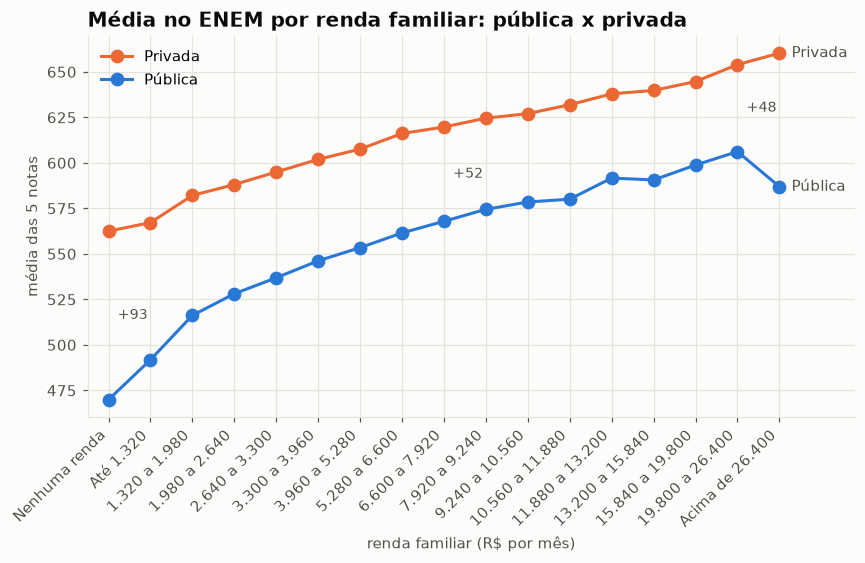

In [5]:
x = range(len(tabela))
fig, ax = plt.subplots(figsize=(9, 4.5))
for rede, cor in [("Privada", LARANJA), ("Pública", AZUL)]:
    ax.plot(x, tabela[rede], color=cor, marker="o", label=rede)
    ax.annotate(rede, (len(tabela) - 1, tabela[rede].iloc[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", color=TEXTO_SECUNDARIO)
for i in (0, 8, 15):
    meio = (tabela["Privada"].iloc[i] + tabela["Pública"].iloc[i]) / 2
    ax.annotate(f"+{tabela['diferença'].iloc[i]:.0f}", (i, meio), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=9, color=TEXTO_SECUNDARIO)
ax.set_xticks(x, tabela.index.astype(str), rotation=45, ha="right")
ax.set_xlim(-0.5, len(tabela) + 0.8)
ax.legend(loc="upper left")
ax.set_title("Média no ENEM por renda familiar: pública x privada")
ax.set_xlabel("renda familiar (R$ por mês)")
ax.set_ylabel("média das 5 notas")
salvar(fig, "02_publica_privada_por_renda");

A privada fica à frente em **todas** as faixas, mas a distância encolhe
conforme a renda sobe: são 93 pontos entre alunos sem renda e uns 50 pontos
nas faixas altas. (A queda da pública na última faixa vem de só 1.214
alunos, o que torna esse ponto instável.)

## 3. Quanto da diferença sobra?

Aplicamos `diferenca_ajustada` com estratos cada vez mais finos. Os pesos são
os alunos da pública: a pergunta é *"quanto um aluno típico da pública
ganharia estudando numa privada, mantido o perfil familiar?"*

In [6]:
controles = {
    "sem ajuste": [],
    "+ renda": ["Q006"],
    "+ escolaridade da mãe": ["Q006", "Q002"],
    "+ escolaridade do pai": ["Q006", "Q002", "Q001"],
}
bruta = base.groupby("TP_ESCOLA", observed=True)["MEDIA"].mean()
diferencas = pd.Series({
    nome: (bruta["Privada"] - bruta["Pública"]) if not estratos
    else diferenca_ajustada(base, "TP_ESCOLA", "Pública", "Privada", estratos)
    for nome, estratos in controles.items()
}, name="diferença privada - pública")
diferencas

sem ajuste              100.3
+ renda                  67.4
+ escolaridade da mãe    62.1
+ escolaridade do pai    60.1
Name: diferença privada - pública, dtype: float64

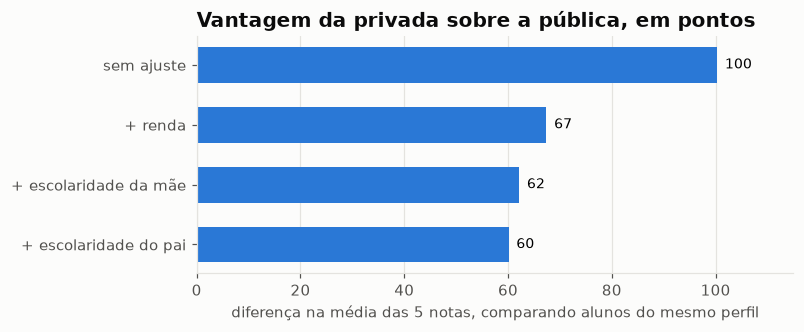

In [7]:
fig, ax = plt.subplots(figsize=(7, 2.8))
serie = diferencas.iloc[::-1]
ax.barh(serie.index, serie.values, color=AZUL, height=0.6)
for y, valor in enumerate(serie.values):
    ax.text(valor + 1.5, y, f"{valor:.0f}", va="center", fontsize=9)
ax.set_xlim(0, 115)
ax.grid(axis="y", visible=False)
ax.set_title("Vantagem da privada sobre a pública, em pontos")
ax.set_xlabel("diferença na média das 5 notas, comparando alunos do mesmo perfil")
salvar(fig, "02_diferenca_ajustada");

**Um terço da vantagem da privada é renda.** Comparando alunos da mesma faixa
de renda, os 100 pontos caem para 67. A escolaridade dos pais tira mais uns
7, e sobram cerca de 60 pontos.

Esses 60 pontos **não são o efeito da escola**. Eles misturam o que a escola
faz com tudo o que o questionário não mede: capital cultural, cursinho,
motivação, e o fato de famílias que escolhem pagar uma escola serem
diferentes de outras com a mesma renda. É uma cota superior, não uma medida
causal.

## 4. Um aluno pobre de escola federal vai melhor que um rico de escola estadual?

In [8]:
redes = ["Federal", "Estadual", "Privada"]
por_rede = base.pivot_table(index="Q006", columns="TP_DEPENDENCIA_ADM_ESC", values="MEDIA",
                            aggfunc="mean", observed=True)[redes]
por_rede

TP_DEPENDENCIA_ADM_ESC,Federal,Estadual,Privada
Q006,,,
Nenhuma renda,545.6,468.0,565.2
Até 1.320,562.7,487.0,567.6
1.320 a 1.980,581.1,511.9,580.8
1.980 a 2.640,592.0,524.1,587.7
2.640 a 3.300,600.1,531.9,594.8
3.300 a 3.960,607.8,540.6,601.0
3.960 a 5.280,611.9,545.8,607.6
5.280 a 6.600,621.7,552.0,615.9
6.600 a 7.920,627.7,556.7,620.0


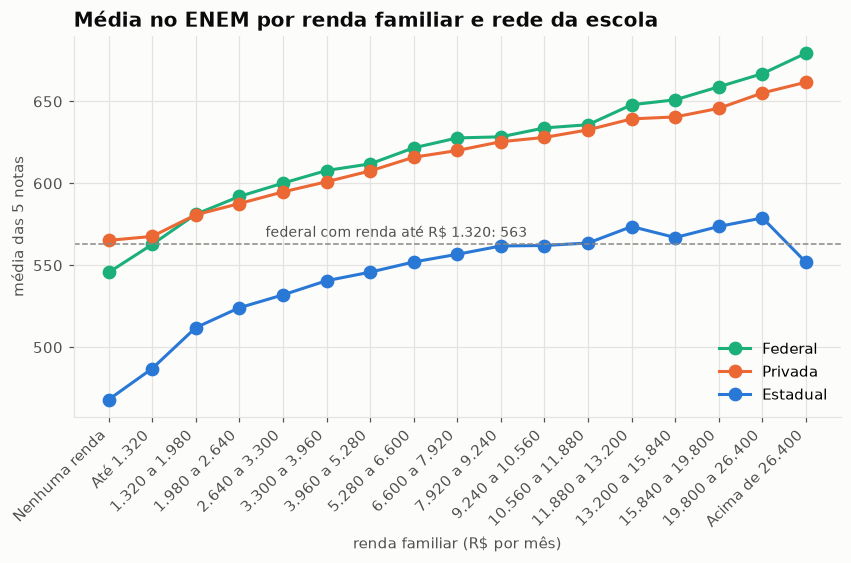

In [9]:
x = range(len(por_rede))
fig, ax = plt.subplots(figsize=(9, 4.5))
for rede, cor in [("Federal", VERDE_AGUA), ("Privada", LARANJA), ("Estadual", AZUL)]:
    ax.plot(x, por_rede[rede], color=cor, marker="o", label=rede)
referencia = por_rede.loc["Até 1.320", "Federal"]
ax.axhline(referencia, color=CINZA, linewidth=1, linestyle="--")
ax.annotate(f"federal com renda até R$ 1.320: {referencia:.0f}", (3.6, referencia),
            xytext=(0, 5), textcoords="offset points", fontsize=9, color=TEXTO_SECUNDARIO)
ax.set_xticks(x, por_rede.index.astype(str), rotation=45, ha="right")
ax.legend(loc="lower right")
ax.set_title("Média no ENEM por renda familiar e rede da escola")
ax.set_xlabel("renda familiar (R$ por mês)")
ax.set_ylabel("média das 5 notas")
salvar(fig, "02_rede_por_renda");

**Sim.** O aluno de escola federal com renda de até R$ 1.320 (563) fica no
nível do aluno de escola estadual de família com mais de R$ 13 mil por mês
(de 552 a 579 nas quatro faixas mais altas). E, a partir de R$ 1.320 de
renda, a federal empata com a privada ou fica à frente; só nas duas faixas mais
baixas ela fica atrás (546 contra 565 entre alunos sem renda).

⚠️ **Cuidado com a leitura causal.** A maioria das escolas federais (institutos
federais, colégios militares, colégios de aplicação) **seleciona os alunos por
prova de ingresso**. Parte da vantagem é de quem entra, não do que a escola
faz. Mesmo assim, o resultado mostra que existe uma rede pública com
desempenho de escola privada.

## 5. Estados: ranking bruto x ranking ajustado pelo perfil

`media_padronizada` calcula a média que cada estado teria se seus alunos
tivessem a **composição nacional** de renda e tipo de escola. Aqui a renda usa
as 5 faixas em salários mínimos, porque 17 faixas × 2 redes × 27 UFs deixaria
muitos grupos com poucos alunos.

In [10]:
estratos = ["RENDA_SM", "TP_ESCOLA"]
tamanhos = base.groupby(["SG_UF_PROVA"] + estratos, observed=True).size()
print(f"menor grupo: {tamanhos.min()} alunos ({', '.join(tamanhos.idxmin())}); "
      f"{(tamanhos < 100).sum()} de {len(tamanhos)} grupos com menos de 100 alunos")

estados = pd.DataFrame({
    "bruta": base.groupby("SG_UF_PROVA", observed=True)["MEDIA"].mean(),
    "ajustada": media_padronizada(base, "SG_UF_PROVA", estratos),
})
estados["efeito do perfil"] = estados["bruta"] - estados["ajustada"]
estados["posição bruta"] = estados["bruta"].rank(ascending=False).astype(int)
estados["posição ajustada"] = estados["ajustada"].rank(ascending=False).astype(int)
estados = estados.sort_values("ajustada", ascending=False)
estados

menor grupo: 11 alunos (RR, Até 1 SM, Privada); 21 de 270 grupos com menos de 100 alunos


,bruta,ajustada,efeito do perfil,posição bruta,posição ajustada
MG,562.6,556.4,6.2,1,1
ES,554.5,553.3,1.2,6,2
RN,541.7,552.1,-10.4,9,3
RS,557.2,547.7,9.5,4,4
PB,526.9,545.1,-18.2,14,5
PE,528.6,544.6,-16.1,12,6
RJ,555.7,541.8,13.9,5,7
SC,557.2,541.4,15.9,3,8
SP,557.3,541.1,16.2,2,9
SE,525.4,540.9,-15.4,16,10


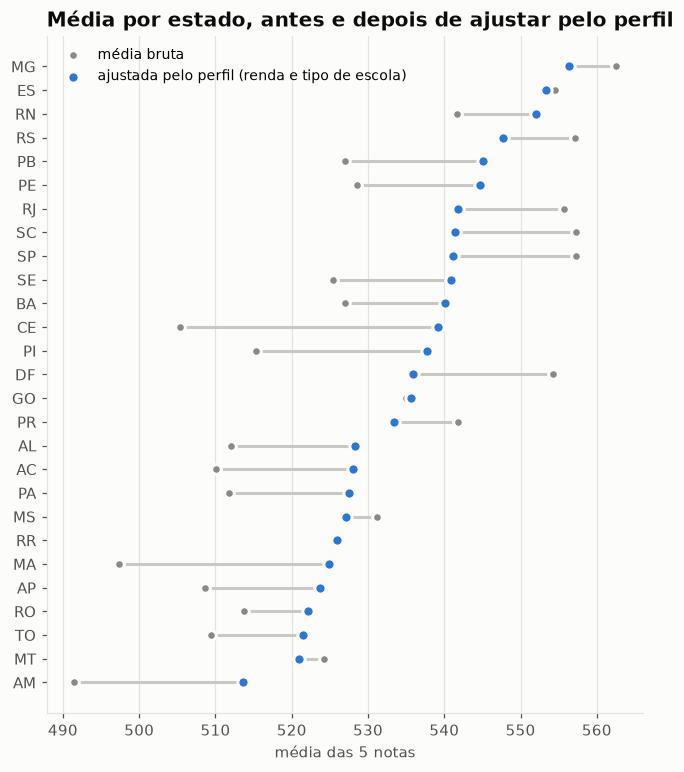

In [11]:
ordem = estados.sort_values("ajustada")
y = range(len(ordem))
fig, ax = plt.subplots(figsize=(7, 8))
ax.hlines(y, ordem["bruta"], ordem["ajustada"], color="#c9c8c3", linewidth=2)
ax.scatter(ordem["bruta"], y, color=CINZA, s=40, zorder=3, label="média bruta",
           edgecolor=SUPERFICIE, linewidth=2)
ax.scatter(ordem["ajustada"], y, color=AZUL, s=55, zorder=3,
           label="ajustada pelo perfil (renda e tipo de escola)",
           edgecolor=SUPERFICIE, linewidth=2)
ax.set_yticks(y, ordem.index)
ax.grid(axis="y", visible=False)
ax.legend(loc="upper left", fontsize=9)
ax.set_title("Média por estado, antes e depois de ajustar pelo perfil")
ax.set_xlabel("média das 5 notas")
salvar(fig, "02_estados_ajustados");

In [12]:
amplitude = estados[["bruta", "ajustada"]].agg(lambda s: s.max() - s.min())
print(f"distância entre o melhor e o pior estado: {amplitude['bruta']:.0f} pontos (bruta) "
      f"-> {amplitude['ajustada']:.0f} (ajustada)")
estados.loc[estados["efeito do perfil"].abs().sort_values(ascending=False).index[:6],
            ["bruta", "ajustada", "posição bruta", "posição ajustada"]]

distância entre o melhor e o pior estado: 71 pontos (bruta) -> 43 (ajustada)


,bruta,ajustada,posição bruta,posição ajustada
CE,505.3,539.1,25,12
MA,497.4,524.8,26,22
PI,515.3,537.8,18,13
AM,491.4,513.6,27,27
DF,554.3,535.9,7,14
PB,526.9,545.1,14,5


Ajustar pelo perfil **encolhe a distância entre os estados de 71 para 43
pontos**, ou seja, cerca de 40% da diferença entre estados é composição (quantos
alunos pobres e de escola pública cada um tem).

- **Quem sobe**: o Nordeste. O Ceará vai de 25º para 12º, PB de 14º para 5º,
  PE de 12º para 6º. Os alunos desses estados vão bem **para o perfil que
  têm**; a média bruta baixa vem de terem muitos alunos pobres.
- **Quem desce**: DF (7º → 14º), SP (2º → 9º) e SC (3º → 8º). Parte da média
  alta vem de uma população mais rica e com mais escola privada.
- **Quem fica**: MG é 1º nos dois rankings e AM é último nos dois. Nesses
  casos o perfil não explica a posição.

## Conclusões

1. **Renda explica um terço da vantagem da privada** (100 → 67 pontos), e a
   escolaridade dos pais leva a 60. O que sobra não é efeito causal da escola:
   inclui tudo o que o questionário não mede.
2. **A rede federal é a exceção da pública**: com renda a partir de R$ 1.320,
   empata com a privada ou a supera. Um aluno pobre de federal vai tão bem
   quanto um rico de estadual. A seleção por prova de ingresso explica parte
   disso.
3. **O ranking de estados é, em boa parte, um ranking de renda.** Ajustado
   pelo perfil, o Nordeste sobe e DF, SP e SC descem.

**Limitações**: a renda é declarada pelo aluno, em faixas; o recorte cobre só
concluintes de 2023 presentes nas 4 provas (quem falta tende a ter perfil
diferente); e padronizar por poucas variáveis deixa de fora confusores como
cursinho e escolaridade de qualidade anterior ao ensino médio.